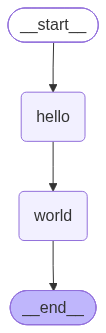


Initial State:
{'message': ''}
Hello node is running...
State received by hello_node: {'message': ''}

World node is running...
State received by world_node: {'message': 'Hello from LangGraph!'}

Final State:
{'message': 'Hello from LangGraph! Welcome to Agentic AI!'}


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    message: str

def hello_node(state: State):
    print("Hello node is running...")
    print("State received by hello_node:", state)
    return {"message": "Hello from LangGraph!"}

def world_node(state: State):
    print("\nWorld node is running...")
    print("State received by world_node:", state)
    return {"message": state["message"] + " Welcome to Agentic AI!"}

graph_builder = StateGraph(State)
graph_builder.add_node("hello", hello_node)
graph_builder.add_node("world", world_node)

graph_builder.add_edge(START, "hello")
graph_builder.add_edge("hello", "world")
graph_builder.add_edge("world", END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

initial_state = {"message": ""}

print("\nInitial State:")
print(initial_state)

result = graph.invoke(initial_state)

print("\nFinal State:")
print(result)